In [45]:
import os
import json
import shutil
import logging
from pathlib import Path
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import normalize
from tqdm.auto import tqdm

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s", datefmt="%H:%M:%S")
log = logging.getLogger(__name__)

print("All imports OK")

All imports OK


In [46]:
# ── Paths ──────────────────────────────────────────────────────────────────
DATA_DIR   = r"C:\Users\King Taylor #8\Desktop\Herb Identification Model 1111\dataset\val"   # root folder with class subfolders
OUTPUT_DIR = r"C:\Users\King Taylor #8\Desktop\val"     # where reports + clean dataset are saved

# ── Outlier Detection ──────────────────────────────────────────────────────
CONTAMINATION  = 0.05   # fraction of images to flag per class (5% = ~35/700)
PCA_COMPONENTS = 64     # dims to reduce embeddings to before Isolation Forest
RANDOM_STATE   = 42

# ── Inference ─────────────────────────────────────────────────────────────
BATCH_SIZE = 64
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
print(f"Device : {DEVICE}")
print(f"Data   : {DATA_DIR}")
print(f"Output : {OUTPUT_DIR}")

Device : cuda
Data   : C:\Users\King Taylor #8\Desktop\Herb Identification Model 1111\dataset\val
Output : C:\Users\King Taylor #8\Desktop\val


## 4. Dataset

In [47]:
class ImageFolderFlat(Dataset):
    """Reads class-subfolder datasets. Returns (tensor, class_name, path)."""
    EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tiff"}

    def __init__(self, root: str, transform):
        self.transform = transform
        self.samples = []
        root = Path(root)
        for class_dir in sorted(root.iterdir()):
            if not class_dir.is_dir():
                continue
            for img_path in sorted(class_dir.iterdir()):
                if img_path.suffix.lower() in self.EXTENSIONS:
                    self.samples.append((str(img_path), class_dir.name))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, class_name = self.samples[idx]
        try:
            img = Image.open(path).convert("RGB")
            tensor = self.transform(img)
        except Exception as e:
            print(f"Warning: failed to load {path}: {e}")
            tensor = torch.zeros(3, 224, 224)
        return tensor, class_name, path

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

dataset = ImageFolderFlat(DATA_DIR, transform)
classes = sorted(set(s[1] for s in dataset.samples))
print(f"Found {len(dataset)} images across {len(classes)} classes")

Found 37675 images across 501 classes


In [ ]:
#Load Model
def load_dinov2(device):
    try:
        print("Loading DINOv2 ViT-B/14 ...")
        model = torch.hub.load("facebookresearch/dinov2", "dinov2_vitb14")
        print("DINOv2 loaded (embedding dim=768)")
    except Exception as e:
        print(f"DINOv2 unavailable ({e}). Falling back to ResNet-50.")
        import torchvision.models as tvm
        backbone = tvm.resnet50(weights=tvm.ResNet50_Weights.IMAGENET1K_V2)
        model = nn.Sequential(*list(backbone.children())[:-1], nn.Flatten())
        print("ResNet-50 loaded (embedding dim=2048)")
    return model.eval().to(device)

model = load_dinov2(DEVICE)

Loading DINOv2 ViT-B/14 ...


Using cache found in C:\Users\King Taylor #8/.cache\torch\hub\facebookresearch_dinov2_main
05:43:10 [INFO] using MLP layer as FFN


DINOv2 loaded (embedding dim=768)


In [49]:
EMBEDDINGS_CACHE = Path(OUTPUT_DIR) / "embeddings_cache.npz"

def extract_embeddings(model, dataset, batch_size, device):
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
    )
    class_data = {}

    with torch.no_grad():
        for batch in tqdm(loader, desc="Extracting embeddings"):
            images, class_names, paths = batch
            images = images.to(device)
            feats  = model(images)
            if feats.dim() == 4:
                feats = feats.squeeze(-1).squeeze(-1)
            feats = feats.cpu().float().numpy()

            for i in range(len(feats)):
                cls  = class_names[i]                    # index, not iterate
                path = paths[i]
                if cls not in class_data:
                    class_data[cls] = {"embeddings": [], "paths": []}
                class_data[cls]["embeddings"].append(feats[i])
                class_data[cls]["paths"].append(path)

    for cls in class_data:
        embs = np.stack(class_data[cls]["embeddings"])
        class_data[cls]["embeddings"] = normalize(embs)

    return class_data


# Delete stale cache first
if EMBEDDINGS_CACHE.exists():
    EMBEDDINGS_CACHE.unlink()
    print("Deleted stale cache")

class_data = extract_embeddings(model, dataset, BATCH_SIZE, DEVICE)
print(f"Extracted {len(class_data)} classes, {sum(len(v['paths']) for v in class_data.values())} images")

# Save fresh cache
np.savez(EMBEDDINGS_CACHE, class_data=class_data)
print("Cache saved")

Extracting embeddings:  14%|█▍        | 84/589 [04:07<23:41,  2.81s/it]

Extracting embeddings:  15%|█▍        | 86/589 [04:12<23:17,  2.78s/it]

Extracting embeddings:  30%|██▉       | 174/589 [08:10<18:43,  2.71s/it]

Extracting embeddings:  63%|██████▎   | 373/589 [17:05<09:05,  2.53s/it]

Extracting embeddings:  64%|██████▎   | 375/589 [17:10<09:09,  2.57s/it]

...

Extracting embeddings:  92%|█████████▏| 542/589 [24:20<02:04,  2.65s/it]

Extracting embeddings:  93%|█████████▎| 547/589 [24:33<01:49,  2.62s/it]

Extracting embeddings:  96%|█████████▋| 568/589 [25:28<00:53,  2.57s/it]

Extracting embeddings: 100%|██████████| 589/589 [26:22<00:00,  2.69s/it]


Extracted 501 classes, 37675 images
Cache saved


In [50]:
# DIAGNOSTIC 1 — paste output here in chat
print(f"Dataset length : {len(dataset)}")
print(f"Sample[0]      : {dataset.samples[0] if dataset.samples else 'EMPTY'}")

Dataset length : 37675
Sample[0]      : ('C:\\Users\\King Taylor #8\\Desktop\\Herb Identification Model 1111\\dataset\\val\\Abelmoschus Esculentus\\313897757.jpg', 'Abelmoschus Esculentus')


In [51]:
# DIAGNOSTIC 2 — paste output here in chat
print(f"class_data keys : {len(class_data)}")
print(f"CONTAMINATION   : {CONTAMINATION}")
print(f"PCA_COMPONENTS  : {PCA_COMPONENTS}")
print(f"RANDOM_STATE    : {RANDOM_STATE}")

class_data keys : 501
CONTAMINATION   : 0.05
PCA_COMPONENTS  : 64
RANDOM_STATE    : 42


In [52]:
def detect_outliers_per_class(class_data, contamination, pca_components, random_state):
    outlier_map   = {}
    total_outliers = 0

    for cls, data in tqdm(class_data.items(), desc="Detecting outliers"):
        embs      = data["embeddings"]
        paths     = data["paths"]
        n_samples = len(paths)

        # PCA
        n_comp  = min(pca_components, n_samples - 1, embs.shape[1])
        reduced = PCA(n_components=n_comp, random_state=random_state).fit_transform(embs)

        # Isolation Forest
        preds = IsolationForest(
            contamination=contamination,
            n_estimators=200,
            random_state=random_state,
            n_jobs=-1,
        ).fit_predict(reduced)

        outlier_paths       = [p for p, pred in zip(paths, preds) if pred == -1]
        outlier_map[cls]    = outlier_paths
        total_outliers     += len(outlier_paths)

    total_images = sum(len(d["paths"]) for d in class_data.values())
    print(f"Outliers flagged: {total_outliers} / {total_images} "
          f"({100 * total_outliers / total_images:.1f}%)")
    return outlier_map


outlier_map = detect_outliers_per_class(
    class_data,
    contamination  = CONTAMINATION,
    pca_components = PCA_COMPONENTS,
    random_state   = RANDOM_STATE,
)

Detecting outliers:   4%|▍         | 20/501 [00:07<02:55,  2.75it/s]c:\Users\King Taylor #8\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\decomposition\_pca.py:584: RuntimeWarning: invalid value encountered in divide
  explained_variance_ = (S**2) / (n_samples - 1)
Detecting outliers:   4%|▍         | 20/501 [00:07<03:03,  2.62it/s]


ValueError: Found array with 0 feature(s) (shape=(1, 0)) while a minimum of 1 is required by IsolationForest.

In [ ]:
import pandas as pd

rows = [
    {
        "class":    cls,
        "total":    len(class_data[cls]["paths"]),
        "outliers": len(paths),
        "clean":    len(class_data[cls]["paths"]) - len(paths),
        "outlier%": round(100 * len(paths) / len(class_data[cls]["paths"]), 1),
    }
    for cls, paths in outlier_map.items()
]

df = pd.DataFrame(rows).sort_values("outliers", ascending=False)
print(f"Total classes  : {len(df)}")
print(f"Total outliers : {df['outliers'].sum()}")
print(f"Total clean    : {df['clean'].sum()}")
print()
print("Top 10 classes by outlier count:")
df.head(10)

Total classes  : 501
Total outliers : 14456
Total clean    : 271943

Top 10 classes by outlier count:


,class,total,outliers,clean,outlier%
183,Coriandrum,1604,81,1523,5.0
353,Melissa,1597,80,1517,5.0
241,Ephedra,1595,80,1515,5.0
223,Dodonaea,1597,80,1517,5.0
286,Helichrysum,1598,80,1518,5.0
210,Daucus,1600,80,1520,5.0
306,Impatiens,1597,80,1517,5.0
301,Hyoscyamus,1598,80,1518,5.0
352,Melia,1597,80,1517,5.0
267,Gardenia,1596,80,1516,5.0


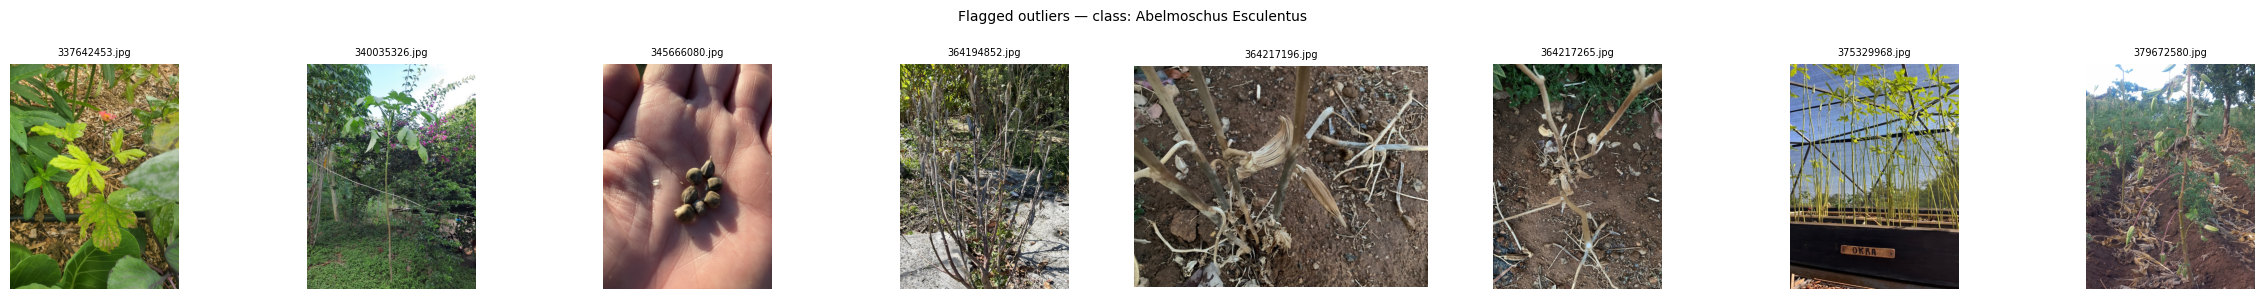

In [ ]:
import matplotlib.pyplot as plt
import random

PREVIEW_CLASS = list(outlier_map.keys())[0]   # change to any class name
PREVIEW_N     = 8                              # number of images to show

sample_paths = outlier_map[PREVIEW_CLASS][:PREVIEW_N]

if not sample_paths:
    print(f"No outliers found in class '{PREVIEW_CLASS}'")
else:
    fig, axes = plt.subplots(1, len(sample_paths), figsize=(3 * len(sample_paths), 3))
    if len(sample_paths) == 1:
        axes = [axes]
    for ax, path in zip(axes, sample_paths):
        img = Image.open(path).convert("RGB")
        ax.imshow(img)
        ax.set_title(Path(path).name, fontsize=7)
        ax.axis("off")
    fig.suptitle(f"Flagged outliers — class: {PREVIEW_CLASS}", fontsize=10)
    plt.tight_layout()
    plt.show()

In [ ]:
output_dir = Path(OUTPUT_DIR)

all_paths     = [p for d in class_data.values() for p in d["paths"]]
outlier_paths = [p for paths in outlier_map.values() for p in paths]
outlier_set   = set(outlier_paths)
clean_paths   = [p for p in all_paths if p not in outlier_set]

with open(output_dir / "outliers.json", "w", encoding="utf-8") as f:
    json.dump(outlier_map, f, indent=2)

(output_dir / "outlier_paths.txt").write_text("\n".join(outlier_paths), encoding="utf-8")
(output_dir / "clean_paths.txt").write_text("\n".join(clean_paths), encoding="utf-8")

summary = {
    cls: {
        "total":    len(class_data[cls]["paths"]),
        "outliers": len(paths),
        "clean":    len(class_data[cls]["paths"]) - len(paths),
    }
    for cls, paths in outlier_map.items()
}
with open(output_dir / "summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print(f"Reports saved to {output_dir}/")
print(f"  Clean images   : {len(clean_paths)}")
print(f"  Outlier images : {len(outlier_paths)}")

Reports saved to G:\Cleaned Dataset (Experimental)/
  Clean images   : 271943
  Outlier images : 14456


In [ ]:
clean_dataset_dir = output_dir / "clean_dataset"
failed = []

for path in tqdm(clean_paths, desc="Copying clean images"):
    src  = Path(path)
    dest = clean_dataset_dir / src.parent.name / src.name
    dest.parent.mkdir(parents=True, exist_ok=True)
    try:
        shutil.copy2(src, dest)
    except Exception as e:
        print(f"Warning: failed to copy {src}: {e}")
        failed.append(str(src))

print(f"Done. {len(clean_paths) - len(failed)} images copied to {clean_dataset_dir}/")

if failed:
    (output_dir / "copy_failures.txt").write_text("\n".join(failed), encoding="utf-8")
    print(f"{len(failed)} failures logged to copy_failures.txt")

Copying clean images: 100%|██████████| 271943/271943 [22:28<00:00, 201.69it/s]

Done. 271943 images copied to G:\Cleaned Dataset (Experimental)\clean_dataset/


In [ ]:
print("=" * 45)
print("  PIPELINE COMPLETE")
print("=" * 45)
print(f"  Original images : {len(all_paths)}")
print(f"  Outliers removed: {len(outlier_paths)}")
print(f"  Clean images    : {len(clean_paths)}")
print()
print("Output:")
print(f"  {output_dir}/clean_dataset/   ← use this for training")
print(f"  {output_dir}/summary.json     ← per-class breakdown")
print(f"  {output_dir}/outliers.json    ← flagged image paths")

  PIPELINE COMPLETE
  Original images : 286399
  Outliers removed: 14456
  Clean images    : 271943

Output:
  G:\Cleaned Dataset (Experimental)/clean_dataset/   ← use this for training
  G:\Cleaned Dataset (Experimental)/summary.json     ← per-class breakdown
  G:\Cleaned Dataset (Experimental)/outliers.json    ← flagged image paths
